# ST3189: Machine Learning — Assessed Coursework Project
**Candidate Number:** `[YOUR CANDIDATE NUMBER]`

---

### Structure
| Section | Task | Dataset | Models |
|---------|------|---------|--------|
| 1 | Unsupervised Learning | FIFA Players | PCA, K-Means, HAC |
| 2 | Supervised Learning (Classification) | Mushrooms | Logistic Regression, SVC, Random Forest |
| 3 | Supervised Learning (Regression) | FIFA Players | Linear, Polynomial, Lasso, Ridge, Random Forest |

> **Data sources**
> - FIFA dataset: `fifa_player_performance_market_value.csv`
> - Mushroom dataset: `mushrooms.csv` (UCI ML Repository — https://archive.ics.uci.edu/ml/datasets/mushroom)


---
## Setup & Imports

In [1]:
# ── Standard libraries ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── Sklearn: preprocessing & decomposition ────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.decomposition import PCA

# ── Sklearn: clustering ────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

# ── Sklearn: models ────────────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso,
    LogisticRegression, RidgeCV, LassoCV
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, KFold
)

# ── Plot aesthetics ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
    'figure.facecolor': 'white'
})
PALETTE = sns.color_palette("Set2")
sns.set_palette("Set2")

print("✓ All libraries loaded successfully.")

✓ All libraries loaded successfully.


In [2]:
# ── Load datasets ──────────────────────────────────────────────────────────
fifa     = pd.read_csv('fifa_player_performance_market_value.csv')
mushroom = pd.read_csv('mushrooms.csv')

print(f"FIFA dataset    : {fifa.shape[0]:,} rows × {fifa.shape[1]} columns")
print(f"Mushroom dataset: {mushroom.shape[0]:,} rows × {mushroom.shape[1]} columns")
print()
display(fifa.head(3))
display(mushroom.head(3))

FIFA dataset    : 2,800 rows × 16 columns
Mushroom dataset: 8,124 rows × 23 columns



,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


---
## 1. Unsupervised Learning

**Research question:** Can data-driven clustering techniques identify natural, homogeneous archetypes
of professional football players based on their performance and market characteristics,
without relying on pre-defined labels?


### 1.2 Data Description

In [3]:
# Features selected for clustering (numeric only)
CLUSTER_FEATS = [
    'age', 'overall_rating', 'potential_rating',
    'matches_played', 'goals', 'assists',
    'minutes_played', 'market_value_million_eur', 'contract_years_left'
]

X_raw = fifa[CLUSTER_FEATS].dropna().copy()
print(f"Clustering dataset: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features")
print("\nMissing values:")
print(X_raw.isnull().sum())
print("\nDescriptive statistics:")
display(X_raw.describe().round(2))

Clustering dataset: 2,800 rows × 9 features

Missing values:
age                         0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
dtype: int64

Descriptive statistics:


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00
mean,27.95,76.87,81.56,27.14,19.26,12.02,2250.10,90.57,2.53
std,6.75,9.92,9.76,15.98,11.57,7.19,1295.46,52.08,1.70
min,17.00,60.00,65.00,0.00,0.00,0.00,0.00,0.67,0.00
25%,22.00,68.00,73.00,13.75,9.00,6.00,1131.25,45.36,1.00
50%,28.00,77.00,82.00,27.00,19.00,12.00,2251.00,89.17,3.00
75%,34.00,85.00,90.00,41.00,30.00,18.00,3366.25,136.68,4.00
max,39.00,94.00,98.00,54.00,39.00,24.00,4497.00,179.96,5.00


In [4]:
# Z-score standardisation — essential for distance-based algorithms
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_raw)

print("Post-scaling means  (should be ~0):", np.round(X_scaled.mean(axis=0), 3))
print("Post-scaling stdevs (should be ~1):", np.round(X_scaled.std(axis=0),  3))

Post-scaling means  (should be ~0): [-0.  0. -0. -0. -0. -0. -0. -0. -0.]
Post-scaling stdevs (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


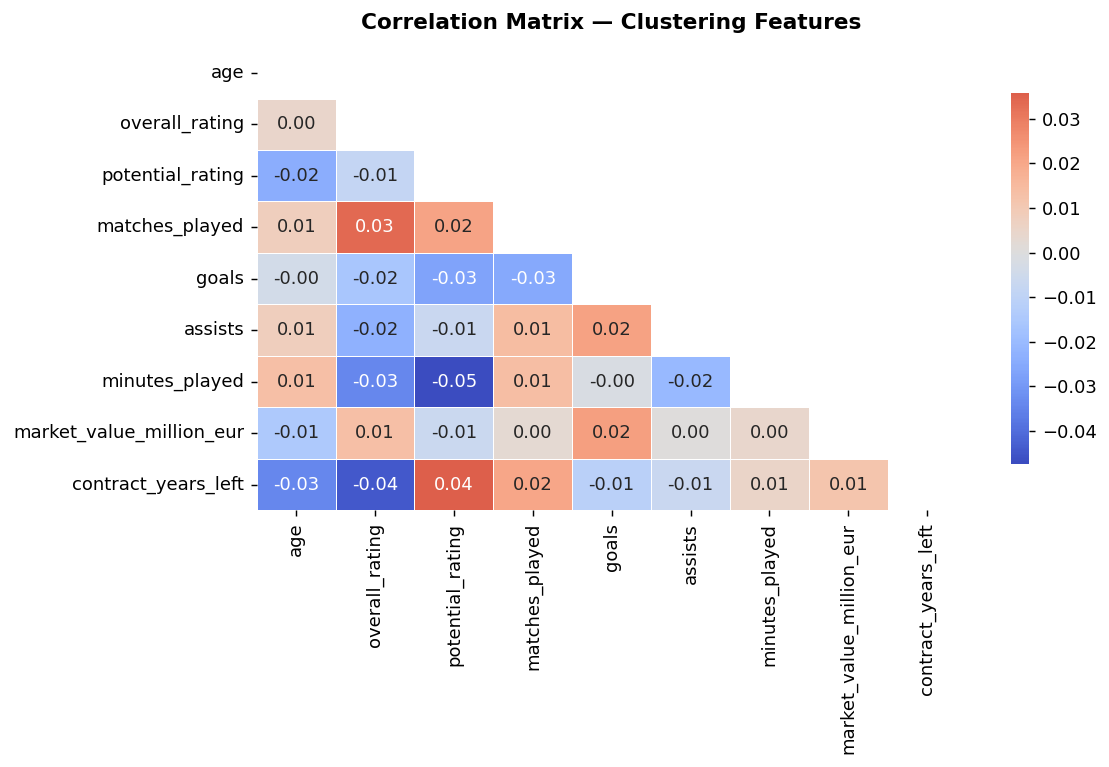

Saved: fig1_correlation_heatmap.png


In [5]:
# ── Correlation heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(X_raw.corr(), dtype=bool))
sns.heatmap(X_raw.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Clustering Features', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig1_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_correlation_heatmap.png")

### 1.3.1 Principal Component Analysis (PCA)

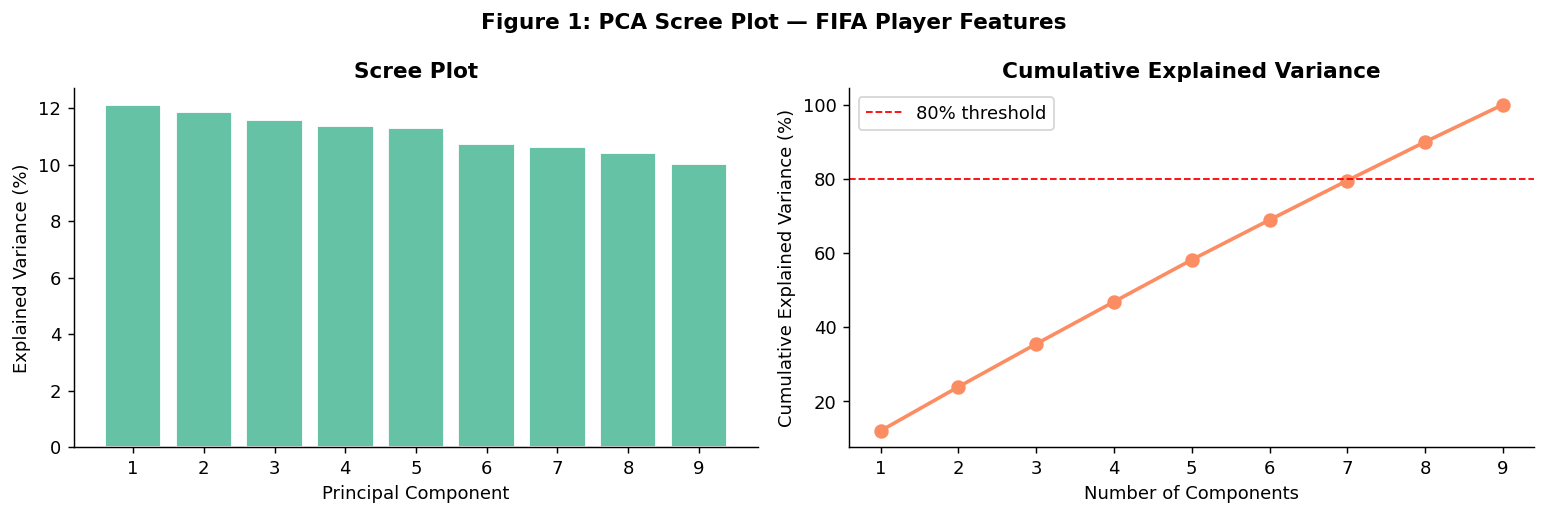

  PC   Explained%   Cumulative%
--------------------------------
   1        12.09         12.09
   2        11.85         23.95
   3        11.57         35.51
   4        11.37         46.88
   5        11.31         58.19
   6        10.75         68.93
   7        10.62         79.55
   8        10.41         89.96
   9        10.04        100.00


In [6]:
# Fit PCA on all 9 components
pca_full = PCA(n_components=len(CLUSTER_FEATS), random_state=42)
pca_full.fit(X_scaled)

explained     = pca_full.explained_variance_ratio_ * 100
cum_explained = np.cumsum(explained)

# ── Scree / cumulative variance plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained)+1), explained, color=PALETTE[0], edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cum_explained)+1), cum_explained,
             'o-', color=PALETTE[1], linewidth=2, markersize=7)
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xticks(range(1, len(cum_explained)+1))
axes[1].legend()

plt.suptitle('Figure 1: PCA Scree Plot — FIFA Player Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_pca_scree.png', bbox_inches='tight')
plt.show()

print(f"{'PC':>4} {'Explained%':>12} {'Cumulative%':>13}")
print("-" * 32)
for i, (e, c) in enumerate(zip(explained, cum_explained), 1):
    print(f"{i:>4} {e:>12.2f} {c:>13.2f}")

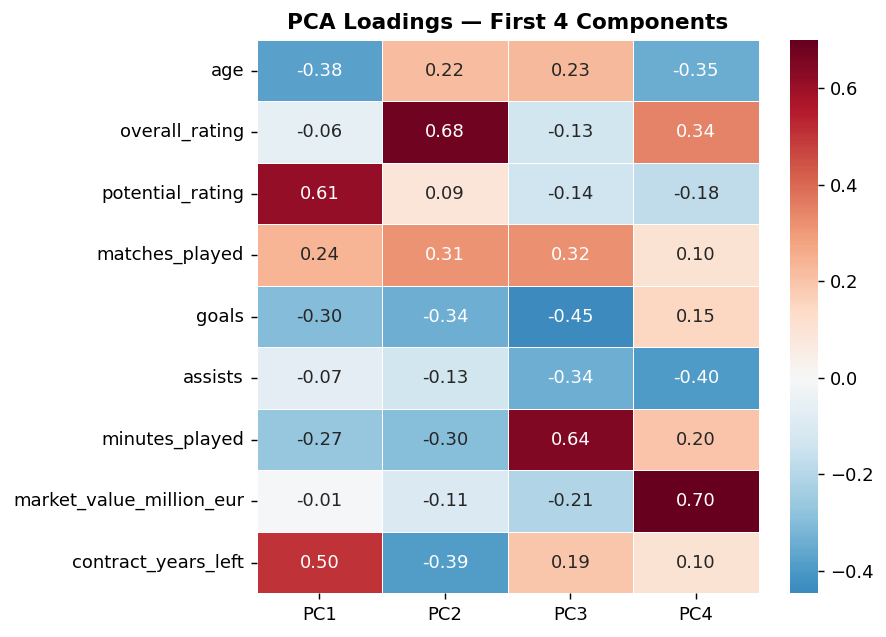

Saved: fig1_pca_loadings.png


In [7]:
# ── PCA loadings heatmap (which features drive each PC) ───────────────────
loadings = pd.DataFrame(
    pca_full.components_[:4].T,
    index=CLUSTER_FEATS,
    columns=[f'PC{i}' for i in range(1, 5)]
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax)
ax.set_title('PCA Loadings — First 4 Components', fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_pca_loadings.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_pca_loadings.png")

### 1.3.2 K-Means Clustering

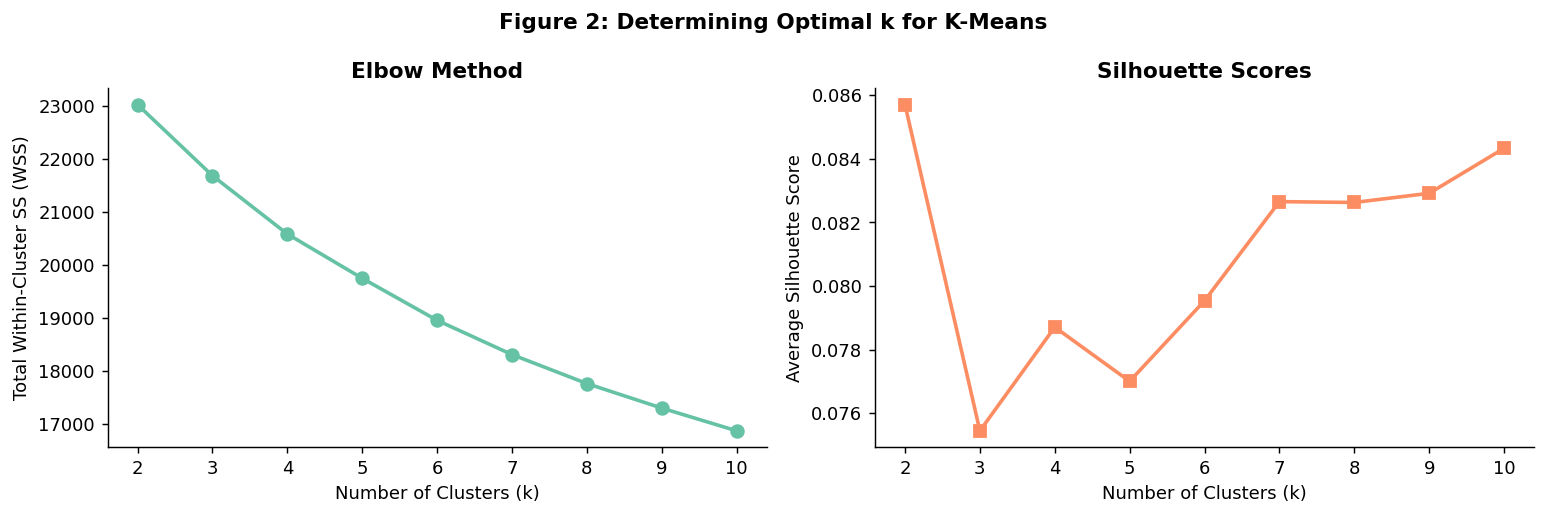

   k           WSS    Silhouette
--------------------------------
   2       23023.6        0.0857 ◄ best
   3       21684.7        0.0755
   4       20585.1        0.0787
   5       19749.8        0.0770
   6       18957.8        0.0795
   7       18311.9        0.0827
   8       17765.5        0.0826
   9       17303.1        0.0829
  10       16874.2        0.0843


In [8]:
# ── Elbow Method + Silhouette Scores ──────────────────────────────────────
wss        = []
sil_scores = []
K_RANGE    = range(2, 11)

for k in K_RANGE:
    km  = KMeans(n_clusters=k, n_init=25, random_state=42)
    lbl = km.fit_predict(X_scaled)
    wss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_RANGE, wss, 'o-', color=PALETTE[0], linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Total Within-Cluster SS (WSS)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(K_RANGE, sil_scores, 's-', color=PALETTE[1], linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('Figure 2: Determining Optimal k for K-Means',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f"{'k':>4}  {'WSS':>12}  {'Silhouette':>12}")
print("-" * 32)
for k, w, s in zip(K_RANGE, wss, sil_scores):
    star = " ◄ best" if s == max(sil_scores) else ""
    print(f"{k:>4}  {w:>12.1f}  {s:>12.4f}{star}")

In [9]:
# ── Set optimal k (update based on elbow/silhouette output above) ─────────
K_OPTIMAL = 4  # ← Update this value based on elbow/silhouette plot above
print(f"\nUsing K_OPTIMAL = {K_OPTIMAL}")


Using K_OPTIMAL = 4


In [10]:
# ── Fit final K-Means ──────────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPTIMAL, n_init=25, random_state=42)
cluster_df = X_raw.copy()
cluster_df['kmeans_cluster'] = km_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(cluster_df['kmeans_cluster'].value_counts().sort_index())

Cluster sizes:
kmeans_cluster
0    736
1    704
2    652
3    708
Name: count, dtype: int64


In [11]:
# ── Cluster centroids in original scale ───────────────────────────────────
centroids = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=CLUSTER_FEATS
).round(2)
centroids.index.name = 'Cluster'
print("=== Cluster Centroids (Original Scale) ===")
display(centroids)

=== Cluster Centroids (Original Scale) ===


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
Cluster,,,,,,,,,
0,29.98,78.30,72.11,27.35,20.18,13.93,2423.14,97.34,1.39
1,27.43,74.33,86.19,28.19,19.24,19.07,2222.20,92.96,3.51
2,26.52,78.94,89.17,27.23,18.86,8.90,1903.92,83.44,1.05
3,27.69,76.01,79.77,25.77,18.71,5.84,2416.15,87.68,4.09


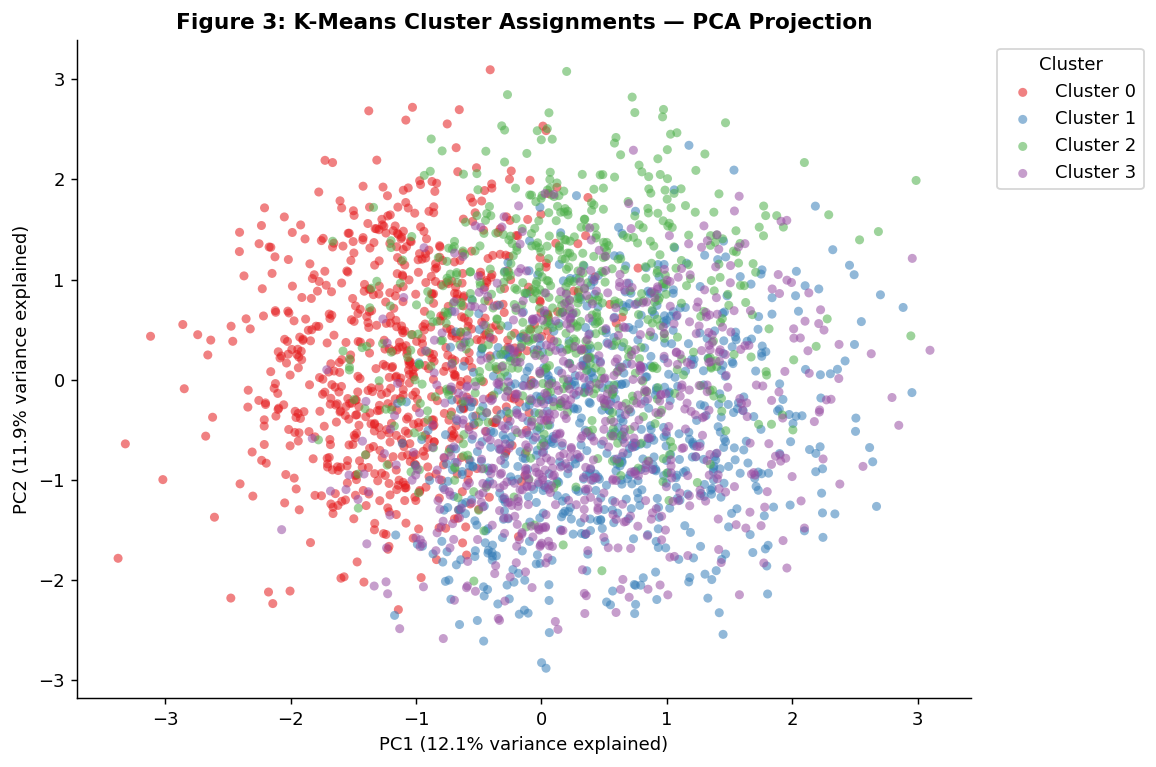

Saved: fig3_kmeans_pca.png


In [12]:
# ── PCA 2D projection of K-Means assignments ──────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
v1, v2 = pca2.explained_variance_ratio_ * 100

# Interpret cluster labels after inspecting centroids — update dict below
CLUSTER_LABELS = {i: f'Cluster {i}' for i in range(K_OPTIMAL)}
# Example after inspection:
# CLUSTER_LABELS = {0: 'Elite Veterans', 1: 'High-Potential Youth',
#                   2: 'Solid Contributors', 3: 'Squad Depth'}

fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette("Set1", K_OPTIMAL)
for c in range(K_OPTIMAL):
    mask = cluster_df['kmeans_cluster'] == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=[pal[c]], label=CLUSTER_LABELS[c],
               alpha=0.55, s=25, edgecolors='none')

ax.set_xlabel(f'PC1 ({v1:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({v2:.1f}% variance explained)')
ax.set_title('Figure 3: K-Means Cluster Assignments — PCA Projection',
             fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig3_kmeans_pca.png', bbox_inches='tight')
plt.show()
print("Saved: fig3_kmeans_pca.png")

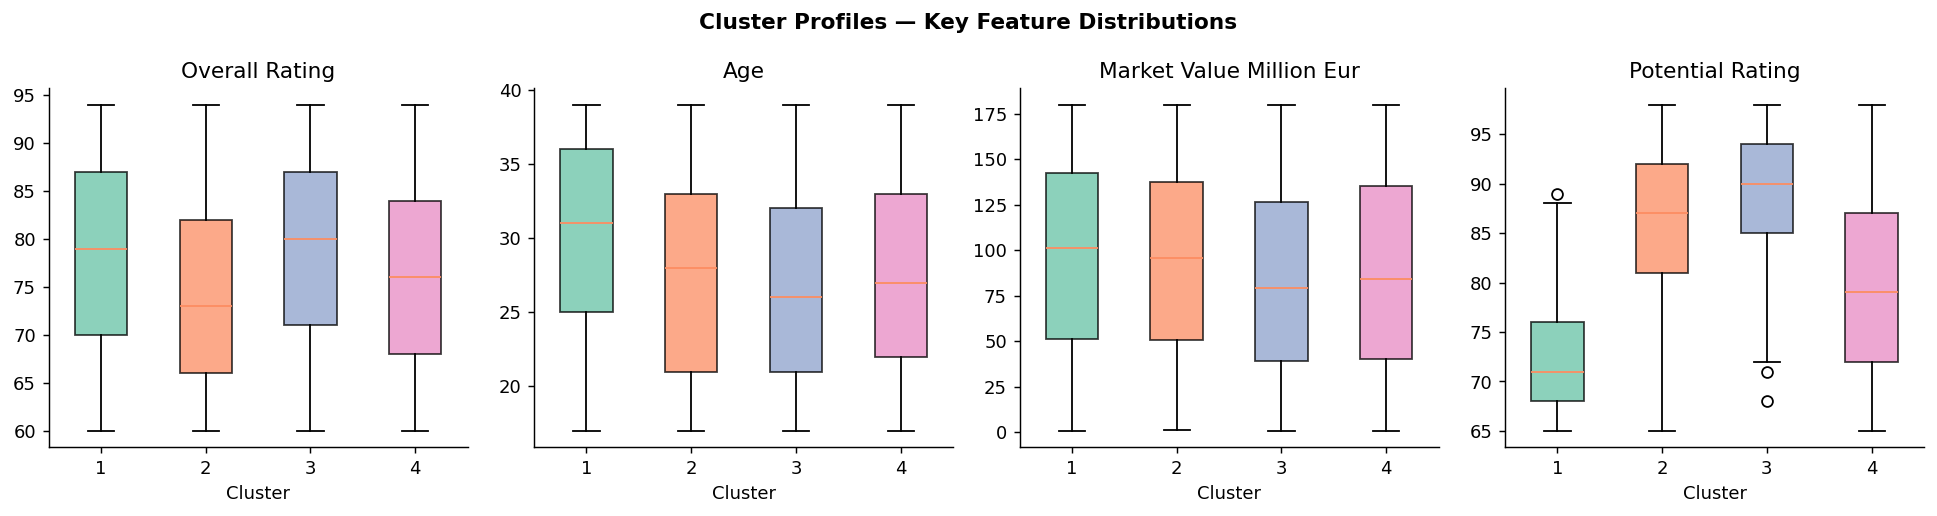

Saved: fig3b_cluster_boxplots.png


In [13]:
# ── Cluster profile boxplots ───────────────────────────────────────────────
KEY_FEATS = ['overall_rating', 'age', 'market_value_million_eur', 'potential_rating']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
pal = sns.color_palette("Set2", K_OPTIMAL)

for ax, feat in zip(axes, KEY_FEATS):
    data = [cluster_df.loc[cluster_df['kmeans_cluster'] == c, feat].values
            for c in range(K_OPTIMAL)]
    bp = ax.boxplot(data, patch_artist=True, notch=False, widths=0.5)
    for patch, color in zip(bp['boxes'], pal):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Cluster')

plt.suptitle('Cluster Profiles — Key Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3b_cluster_boxplots.png', bbox_inches='tight')
plt.show()
print("Saved: fig3b_cluster_boxplots.png")

### 1.3.3 Hierarchical Agglomerative Clustering (HAC)

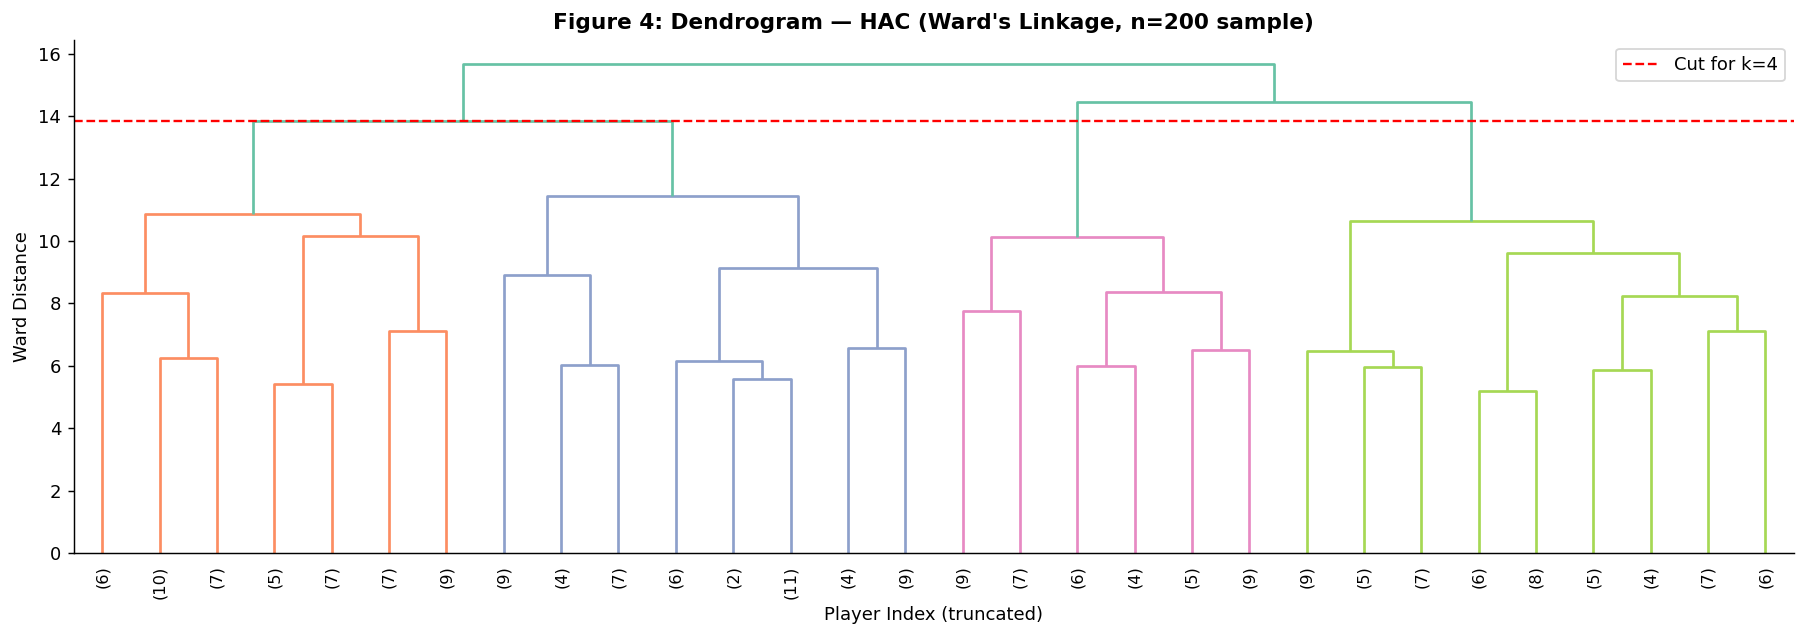

Saved: fig4_dendrogram.png


In [14]:
# ── Dendrogram on 200-player sample for legibility ────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=200, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

cut_height = Z[-(K_OPTIMAL - 1), 2]

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=cut_height)
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.3,
           label=f'Cut for k={K_OPTIMAL}')
ax.set_title("Figure 4: Dendrogram — HAC (Ward's Linkage, n=200 sample)",
             fontweight='bold')
ax.set_xlabel('Player Index (truncated)')
ax.set_ylabel("Ward Distance")
ax.legend()
plt.tight_layout()
plt.savefig('fig4_dendrogram.png', bbox_inches='tight')
plt.show()
print("Saved: fig4_dendrogram.png")

In [15]:
# ── Fit HAC on full dataset ────────────────────────────────────────────────
hac = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
cluster_df['hac_cluster'] = hac.fit_predict(X_scaled)

print("HAC cluster sizes:")
print(cluster_df['hac_cluster'].value_counts().sort_index())

# ── Adjusted Rand Index ────────────────────────────────────────────────────
ari = adjusted_rand_score(cluster_df['kmeans_cluster'], cluster_df['hac_cluster'])
print(f"\nAdjusted Rand Index (K-Means vs HAC): {ari:.4f}")
print("Interpretation: ARI close to 1.0 = strong agreement between methods")

HAC cluster sizes:
hac_cluster
0    1006
1     644
2     535
3     615
Name: count, dtype: int64

Adjusted Rand Index (K-Means vs HAC): 0.0666
Interpretation: ARI close to 1.0 = strong agreement between methods


In [16]:
# ── Cross-tabulation ───────────────────────────────────────────────────────
ct = pd.crosstab(cluster_df['kmeans_cluster'], cluster_df['hac_cluster'],
                 rownames=['K-Means'], colnames=['HAC'])
print("Cross-tabulation of K-Means vs HAC assignments:")
display(ct)

Cross-tabulation of K-Means vs HAC assignments:


HAC,0,1,2,3
K-Means,,,,
0,174,33,285,244
1,295,132,148,129
2,301,160,40,151
3,236,319,62,91


### 1.4 Model Evaluation

In [17]:
# ── Summary evaluation table ───────────────────────────────────────────────
km_sil = silhouette_score(X_scaled, cluster_df['kmeans_cluster'])
hc_sil = silhouette_score(X_scaled, cluster_df['hac_cluster'])

eval_df = pd.DataFrame({
    'Method':          ['K-Means', 'HAC (Ward)'],
    'Silhouette Score': [round(km_sil, 4), round(hc_sil, 4)],
    'Inertia (WSS)':   [round(km_final.inertia_, 1), '—'],
    'ARI vs other':    [round(ari, 4), round(ari, 4)]
})
print("=== Clustering Evaluation Summary ===")
display(eval_df)

=== Clustering Evaluation Summary ===


,Method,Silhouette Score,Inertia (WSS),ARI vs other
0,K-Means,0.0787,20585.1,0.0666
1,HAC (Ward),0.0299,—,0.0666


---
## 2. Supervised Learning (Classification)

**Research question:** Can the physical characteristics of a mushroom reliably predict whether
it is edible or poisonous — and which model achieves the best performance?

**Priority metric:** Recall for the **poisonous class** (false negatives are safety-critical).


### 2.2 Dataset Description

Class counts:
class
e    4208
p    3916
Name: count, dtype: int64


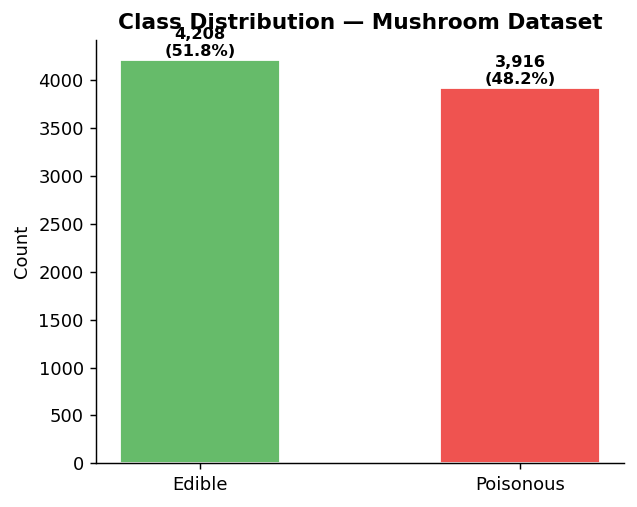

In [18]:
# ── Class distribution ─────────────────────────────────────────────────────
print("Class counts:")
print(mushroom['class'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
counts = mushroom['class'].map({'e': 'Edible', 'p': 'Poisonous'}).value_counts()
ax.bar(counts.index, counts.values,
       color=['#66BB6A', '#EF5350'], edgecolor='white', width=0.5)
ax.set_ylabel('Count')
ax.set_title('Class Distribution — Mushroom Dataset', fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f'{v:,}\n({v/len(mushroom)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('fig_clf_class_dist.png', bbox_inches='tight')
plt.show()

In [19]:
# ── Drop veil-type (single unique value — no discriminatory power) ─────────
print("Unique values per feature:")
for col in mushroom.columns:
    print(f"  {col:35s}: {mushroom[col].nunique()} unique")

mush = mushroom.drop(columns=['veil-type']).copy()
print(f"\nDropped veil-type. Remaining features: {mush.shape[1] - 1}")

Unique values per feature:
  class                              : 2 unique
  cap-shape                          : 6 unique
  cap-surface                        : 4 unique
  cap-color                          : 10 unique
  bruises                            : 2 unique
  odor                               : 9 unique
  gill-attachment                    : 2 unique
  gill-spacing                       : 2 unique
  gill-size                          : 2 unique
  gill-color                         : 12 unique
  stalk-shape                        : 2 unique
  stalk-root                         : 5 unique
  stalk-surface-above-ring           : 4 unique
  stalk-surface-below-ring           : 4 unique
  stalk-color-above-ring             : 9 unique
  stalk-color-below-ring             : 9 unique
  veil-type                          : 1 unique
  veil-color                         : 4 unique
  ring-number                        : 3 unique
  ring-type                          : 5 unique
  spore-pri

In [20]:
# ── Encode target: 1 = poisonous, 0 = edible ──────────────────────────────
mush['target'] = (mush['class'] == 'p').astype(int)
X_mush = pd.get_dummies(mush.drop(columns=['class', 'target']), drop_first=True)
y_mush = mush['target']

print(f"Feature matrix after one-hot encoding: {X_mush.shape}")
print(f"Class balance: {y_mush.mean()*100:.1f}% poisonous")

Feature matrix after one-hot encoding: (8124, 95)
Class balance: 48.2% poisonous


In [21]:
# ── Train / test split (stratified) ───────────────────────────────────────
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mush, y_mush, test_size=0.2, stratify=y_mush, random_state=42
)
print(f"Training : {X_tr_m.shape[0]:,} | Test: {X_te_m.shape[0]:,}")

Training : 6,499 | Test: 1,625


### 2.4.1 Logistic Regression

In [22]:
# L2-regularised logistic regression
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_tr_m, y_tr_m)

y_pred_lr_clf = log_reg.predict(X_te_m)
y_prob_lr_clf = log_reg.predict_proba(X_te_m)[:, 1]

print("Logistic Regression — Classification Report:")
print(classification_report(y_te_m, y_pred_lr_clf,
                             target_names=['Edible', 'Poisonous']))

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



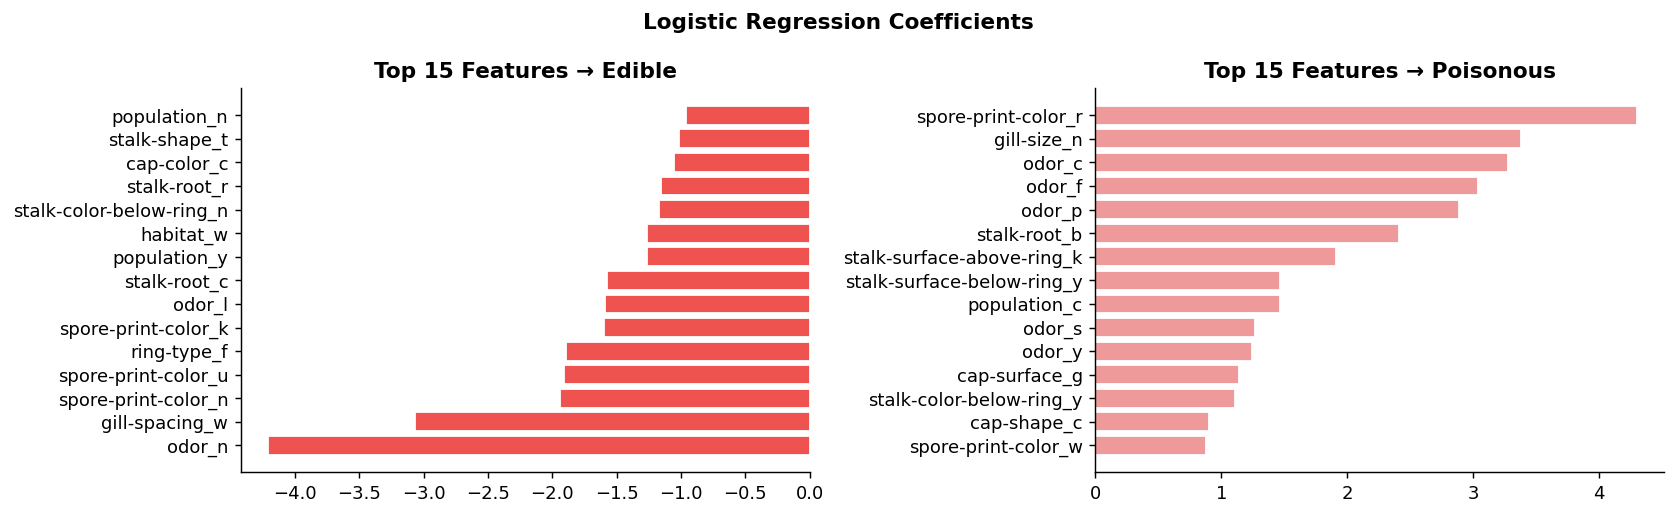

In [23]:
# Top positive/negative coefficients (most discriminative features)
coef_df = pd.DataFrame({
    'feature':     X_mush.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top_pos = coef_df.tail(15)
top_neg = coef_df.head(15)

axes[0].barh(top_neg['feature'], top_neg['coefficient'],
             color='#EF5350', edgecolor='white')
axes[0].set_title('Top 15 Features → Edible', fontweight='bold')

axes[1].barh(top_pos['feature'], top_pos['coefficient'],
             color='#EF9A9A', edgecolor='white')
axes[1].set_title('Top 15 Features → Poisonous', fontweight='bold')

plt.suptitle('Logistic Regression Coefficients', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', bbox_inches='tight')
plt.show()

### 2.4.2 Support Vector Classification (SVC)

In [24]:
# Grid search over C and gamma with RBF kernel
# Note: SVC is slow on large data — we use a subset for CV tuning,
#       then refit on full training set with the best params.
param_grid = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

svc_base = SVC(kernel='rbf', probability=True, random_state=42)
grid_svc = GridSearchCV(svc_base, param_grid, cv=3,
                        scoring='recall', n_jobs=-1, verbose=0)
grid_svc.fit(X_tr_m, y_tr_m)

print(f"Best SVC params : {grid_svc.best_params_}")
print(f"Best CV Recall  : {grid_svc.best_score_:.4f}")

svc_best = grid_svc.best_estimator_
y_pred_svc = svc_best.predict(X_te_m)
y_prob_svc = svc_best.predict_proba(X_te_m)[:, 1]

print("\nSVC — Classification Report:")
print(classification_report(y_te_m, y_pred_svc,
                             target_names=['Edible', 'Poisonous']))

Best SVC params : {'C': 1, 'gamma': 'scale'}
Best CV Recall  : 0.9984



SVC — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### 2.4.3 Random Forest Classifier

In [25]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_tr_m, y_tr_m)

y_pred_rf_clf = rf_clf.predict(X_te_m)
y_prob_rf_clf = rf_clf.predict_proba(X_te_m)[:, 1]

print("Random Forest — Classification Report:")
print(classification_report(y_te_m, y_pred_rf_clf,
                             target_names=['Edible', 'Poisonous']))

Random Forest — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



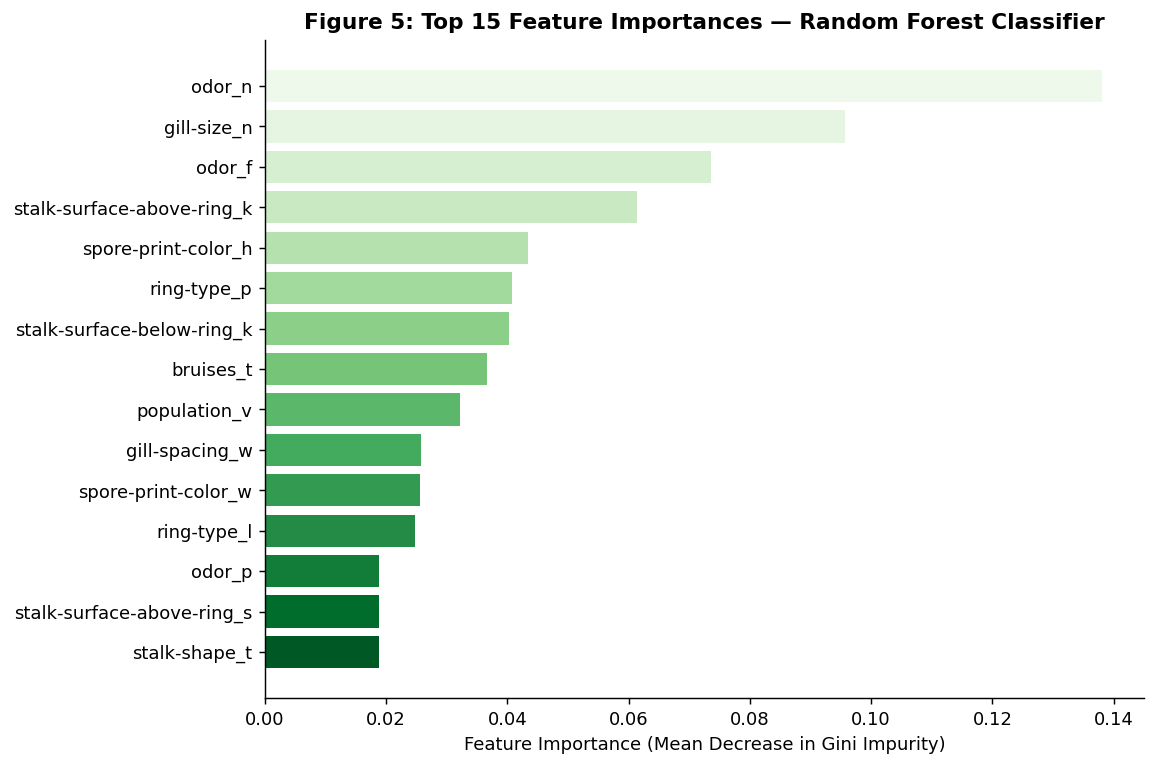

Saved: fig5_rf_feature_importance_clf.png


In [26]:
# Feature importance
feat_imp_clf = pd.Series(
    rf_clf.feature_importances_, index=X_mush.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_clf.index, feat_imp_clf.values,
        color=sns.color_palette("Greens_r", 15))
ax.set_xlabel('Feature Importance (Mean Decrease in Gini Impurity)')
ax.set_title('Figure 5: Top 15 Feature Importances — Random Forest Classifier',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_rf_feature_importance_clf.png', bbox_inches='tight')
plt.show()
print("Saved: fig5_rf_feature_importance_clf.png")

### 2.5 Model Evaluation

In [27]:
# ── Metrics helper ─────────────────────────────────────────────────────────
def clf_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model':           name,
        'Accuracy':        round(accuracy_score(y_true, y_pred), 4),
        'Precision (P)':   round(precision_score(y_true, y_pred), 4),
        'Recall (P)':      round(recall_score(y_true, y_pred), 4),
        'F1 (P)':          round(f1_score(y_true, y_pred), 4),
        'AUC-ROC':         round(roc_auc_score(y_true, y_prob), 4)
    }

results_clf = pd.DataFrame([
    clf_metrics(y_te_m, y_pred_lr_clf,  y_prob_lr_clf,  'Logistic Regression'),
    clf_metrics(y_te_m, y_pred_svc,     y_prob_svc,     'SVC (RBF)'),
    clf_metrics(y_te_m, y_pred_rf_clf,  y_prob_rf_clf,  'Random Forest')
])

print("=== Table 4: Classification Performance (Test Set) ===")
display(results_clf.set_index('Model'))

=== Table 4: Classification Performance (Test Set) ===


,Accuracy,Precision (P),Recall (P),F1 (P),AUC-ROC
Model,,,,,
Logistic Regression,0.9988,1.0,0.9974,0.9987,1.0
SVC (RBF),1.0000,1.0,1.0000,1.0000,1.0
Random Forest,1.0000,1.0,1.0000,1.0000,1.0


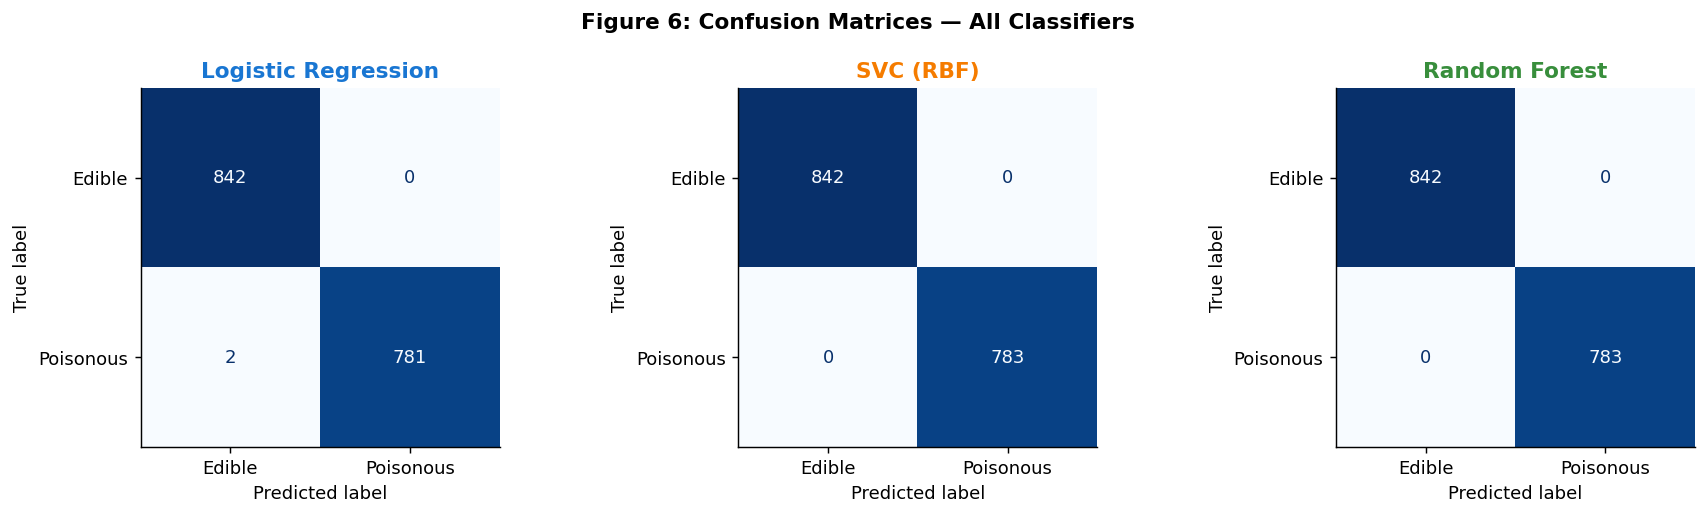

Saved: fig6_confusion_matrices.png


In [28]:
# ── Confusion matrices (Figure 6) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
clf_info = [
    ('Logistic Regression', y_pred_lr_clf, '#1976D2'),
    ('SVC (RBF)',            y_pred_svc,   '#F57C00'),
    ('Random Forest',        y_pred_rf_clf,'#388E3C')
]

for ax, (name, y_pred, color) in zip(axes, clf_info):
    cm   = confusion_matrix(y_te_m, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Edible', 'Poisonous'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', color=color)

plt.suptitle('Figure 6: Confusion Matrices — All Classifiers',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: fig6_confusion_matrices.png")

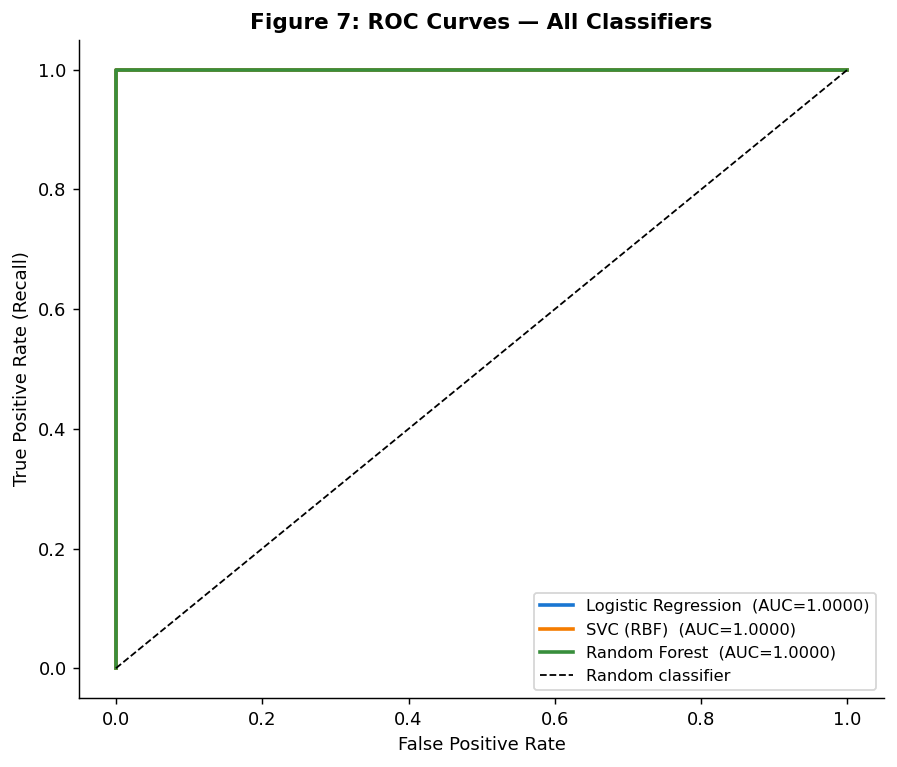

Saved: fig7_roc_curves_clf.png


In [29]:
# ── ROC Curves (Figure 7) ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
roc_models = [
    ('Logistic Regression', y_prob_lr_clf,  '#1976D2'),
    ('SVC (RBF)',            y_prob_svc,    '#F57C00'),
    ('Random Forest',        y_prob_rf_clf, '#388E3C')
]

for name, y_prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_te_m, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={roc_auc:.4f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Figure 7: ROC Curves — All Classifiers', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig7_roc_curves_clf.png', bbox_inches='tight')
plt.show()
print("Saved: fig7_roc_curves_clf.png")

---
## 3. Supervised Learning (Regression)

**Research question:** Which player attributes most strongly determine a footballer's market
value, and which regression model best predicts it?


### 3.2 Data Description

In [30]:
# ── Prepare regression dataframe ──────────────────────────────────────────
reg_df = fifa.drop(columns=['player_id', 'player_name', 'nationality', 'club']).copy()

# Encode categoricals
reg_df['injury_prone']       = (reg_df['injury_prone'] == 'Yes').astype(int)
reg_df['transfer_risk_level'] = reg_df['transfer_risk_level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2}
)
reg_df = pd.get_dummies(reg_df, columns=['position'], drop_first=True)

print(f"Regression dataset: {reg_df.shape}")
display(reg_df.describe().round(2))

Regression dataset: (2800, 19)


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
count,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00
mean,27.95,76.87,81.56,27.14,19.26,12.02,2250.10,90.57,2.53,0.24,0.75
std,6.75,9.92,9.76,15.98,11.57,7.19,1295.46,52.08,1.70,0.43,0.77
min,17.00,60.00,65.00,0.00,0.00,0.00,0.00,0.67,0.00,0.00,0.00
25%,22.00,68.00,73.00,13.75,9.00,6.00,1131.25,45.36,1.00,0.00,0.00
50%,28.00,77.00,82.00,27.00,19.00,12.00,2251.00,89.17,3.00,0.00,1.00
75%,34.00,85.00,90.00,41.00,30.00,18.00,3366.25,136.68,4.00,0.00,1.00
max,39.00,94.00,98.00,54.00,39.00,24.00,4497.00,179.96,5.00,1.00,2.00


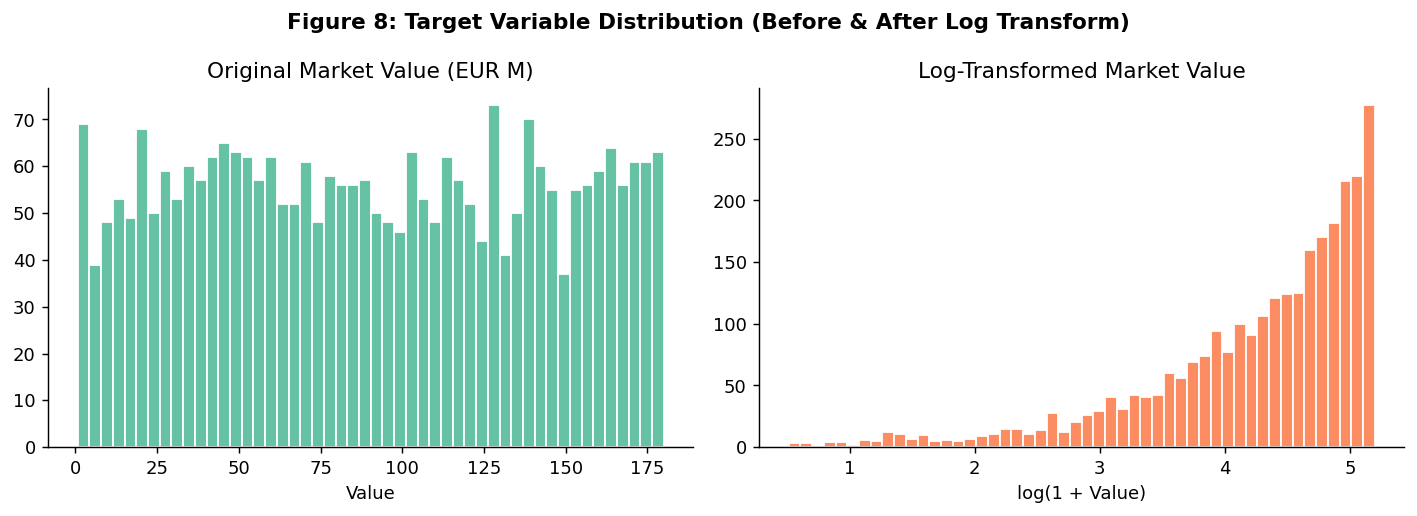

Saved: fig8_target_distribution.png


In [31]:
# ── Log-transform target ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(reg_df['market_value_million_eur'], bins=50,
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Original Market Value (EUR M)')
axes[0].set_xlabel('Value')

reg_df['log_market_value'] = np.log1p(reg_df['market_value_million_eur'])

axes[1].hist(reg_df['log_market_value'], bins=50,
             color=PALETTE[1], edgecolor='white')
axes[1].set_title('Log-Transformed Market Value')
axes[1].set_xlabel('log(1 + Value)')

plt.suptitle('Figure 8: Target Variable Distribution (Before & After Log Transform)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_target_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: fig8_target_distribution.png")

In [32]:
# ── Feature / target split + train-test split ─────────────────────────────
FEAT_COLS = [c for c in reg_df.columns
             if c not in ['market_value_million_eur', 'log_market_value']]

X_reg = reg_df[FEAT_COLS]
y_reg = reg_df['log_market_value']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train: {X_tr_r.shape[0]:,} | Test: {X_te_r.shape[0]:,} | Features: {X_tr_r.shape[1]}")

Train: 2,240 | Test: 560 | Features: 18


### 3.4.1 Linear Regression (Base and Polynomial)

In [33]:
# ── Base OLS ───────────────────────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X_tr_r, y_tr_r)
y_pred_ols = ols.predict(X_te_r)

rmse_ols = np.sqrt(mean_squared_error(y_te_r, y_pred_ols))
mae_ols  = mean_absolute_error(y_te_r, y_pred_ols)
r2_ols   = r2_score(y_te_r, y_pred_ols)

print(f"OLS Linear Regression")
print(f"  RMSE : {rmse_ols:.4f}  |  MAE : {mae_ols:.4f}  |  R² : {r2_ols:.4f}")

OLS Linear Regression
  RMSE : 0.8917  |  MAE : 0.6962  |  R² : -0.0090


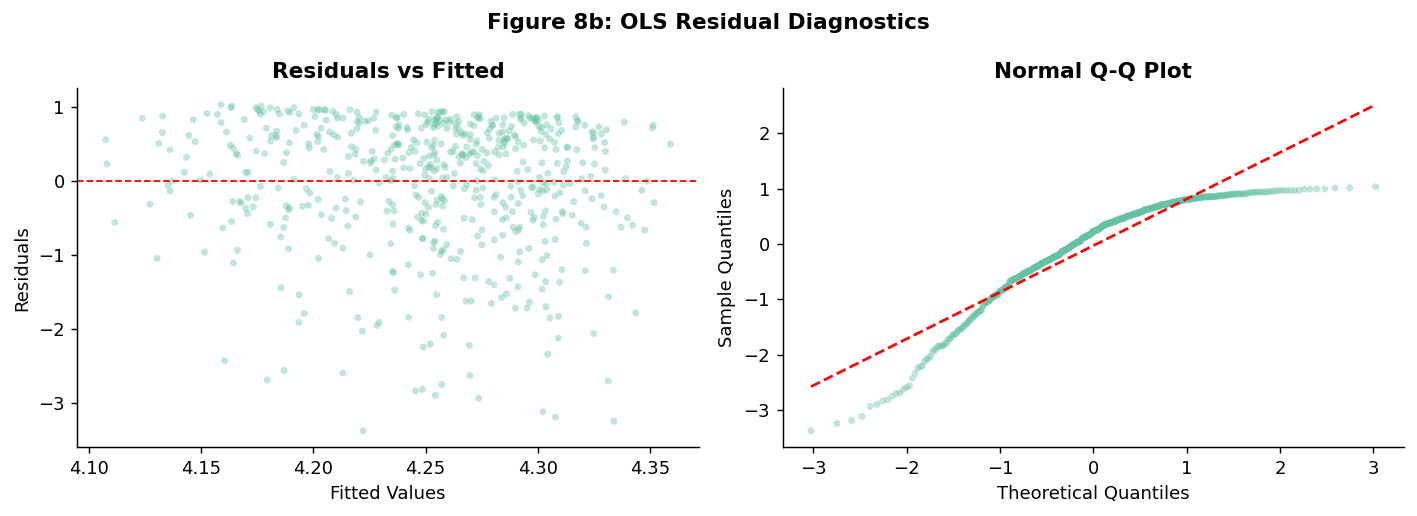

In [34]:
# ── Residual diagnostic plots ──────────────────────────────────────────────
residuals_ols = y_te_r.values - y_pred_ols
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.4, s=15,
                color=PALETTE[0], edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_ols, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=15, color=PALETTE[0], edgecolors='none')
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('Normal Q-Q Plot', fontweight='bold')

plt.suptitle('Figure 8b: OLS Residual Diagnostics', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8b_ols_residuals.png', bbox_inches='tight')
plt.show()

In [35]:
# ── Polynomial Regression (degree 2) ──────────────────────────────────────
poly = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr_r)
X_te_poly  = poly.transform(X_te_r)

print(f"Polynomial feature count (degree=2): {X_tr_poly.shape[1]}")

ols_poly = LinearRegression()
ols_poly.fit(X_tr_poly, y_tr_r)
y_pred_poly = ols_poly.predict(X_te_poly)

rmse_poly = np.sqrt(mean_squared_error(y_te_r, y_pred_poly))
mae_poly  = mean_absolute_error(y_te_r, y_pred_poly)
r2_poly   = r2_score(y_te_r, y_pred_poly)
r2_poly_train = r2_score(y_tr_r, ols_poly.predict(X_tr_poly))

print(f"\nPolynomial Regression (degree=2)")
print(f"  Train R² : {r2_poly_train:.4f}")
print(f"  Test  R² : {r2_poly:.4f}")
print(f"  RMSE     : {rmse_poly:.4f}  |  MAE : {mae_poly:.4f}")
if r2_poly_train - r2_poly > 0.1:
    print("  ⚠ Large train-test R² gap — overfitting detected → use regularisation")

Polynomial feature count (degree=2): 189

Polynomial Regression (degree=2)
  Train R² : 0.0685
  Test  R² : -0.0991
  RMSE     : 0.9306  |  MAE : 0.7231
  ⚠ Large train-test R² gap — overfitting detected → use regularisation


### 3.4.2 Regularization Regression (Lasso and Ridge)

In [36]:
# ── Ridge (L2) with cross-validated alpha ─────────────────────────────────
alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_tr_poly, y_tr_r)
y_pred_ridge = ridge_cv.predict(X_te_poly)

rmse_ridge = np.sqrt(mean_squared_error(y_te_r, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_te_r, y_pred_ridge)
r2_ridge   = r2_score(y_te_r, y_pred_ridge)

print(f"Ridge Regression")
print(f"  Best alpha : {ridge_cv.alpha_:.4f}")
print(f"  RMSE       : {rmse_ridge:.4f}  |  MAE : {mae_ridge:.4f}  |  R² : {r2_ridge:.4f}")

Ridge Regression
  Best alpha : 1000.0000
  RMSE       : 0.9125  |  MAE : 0.7083  |  R² : -0.0568


In [37]:
# ── Lasso (L1) with cross-validated alpha ─────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_tr_poly, y_tr_r)
y_pred_lasso = lasso_cv.predict(X_te_poly)

rmse_lasso = np.sqrt(mean_squared_error(y_te_r, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_te_r, y_pred_lasso)
r2_lasso   = r2_score(y_te_r, y_pred_lasso)

# How many features did Lasso zero out?
n_zero    = (lasso_cv.coef_ == 0).sum()
n_nonzero = (lasso_cv.coef_ != 0).sum()

print(f"Lasso Regression")
print(f"  Best alpha  : {lasso_cv.alpha_:.4f}")
print(f"  Non-zero coefficients: {n_nonzero} / {len(lasso_cv.coef_)} ({n_nonzero/len(lasso_cv.coef_)*100:.1f}% retained)")
print(f"  RMSE        : {rmse_lasso:.4f}  |  MAE : {mae_lasso:.4f}  |  R² : {r2_lasso:.4f}")

Lasso Regression
  Best alpha  : 1000.0000
  Non-zero coefficients: 1 / 189 (0.5% retained)
  RMSE        : 0.8885  |  MAE : 0.6939  |  R² : -0.0020


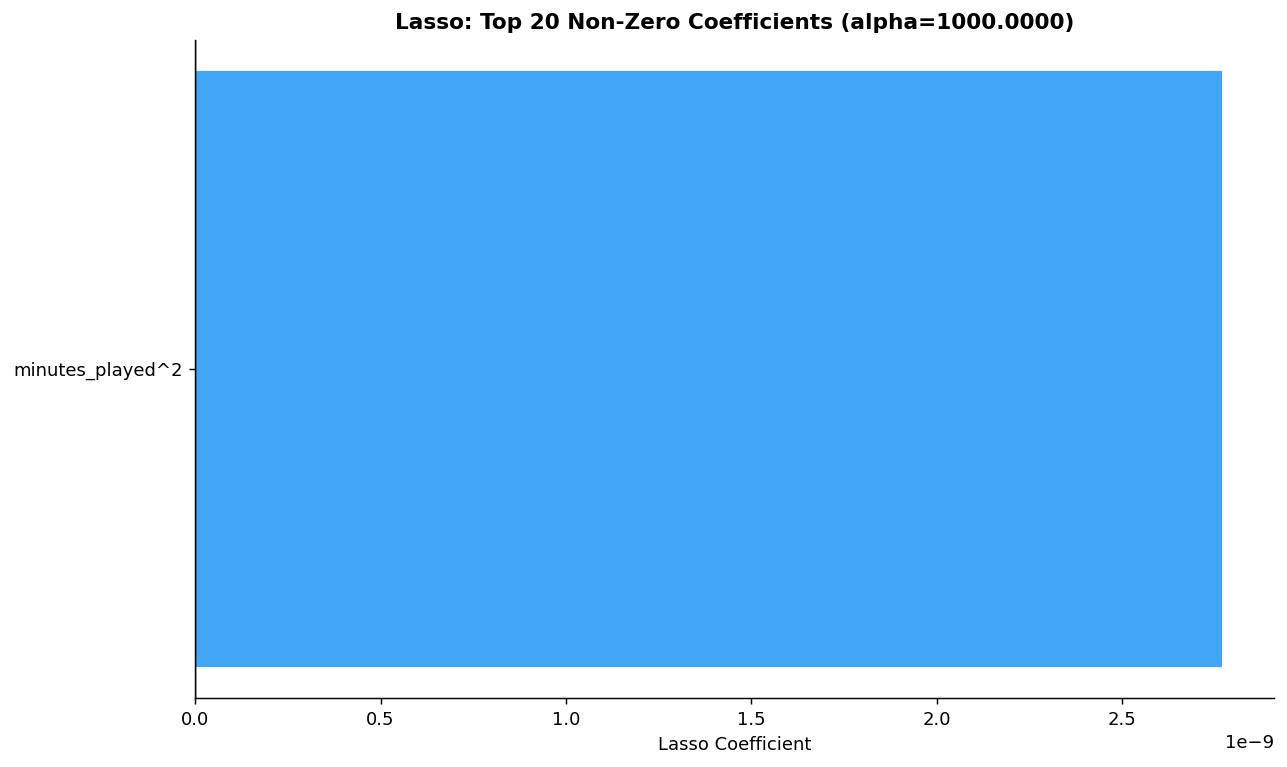

In [38]:
# ── Lasso coefficient path (regularisation path) ──────────────────────────
# Show which polynomial features survive Lasso selection
poly_feat_names = poly.get_feature_names_out(FEAT_COLS)
nonzero_feats   = pd.Series(lasso_cv.coef_, index=poly_feat_names)
nonzero_feats   = nonzero_feats[nonzero_feats != 0].sort_values()

top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#EF5350' if v < 0 else '#42A5F5' for v in nonzero_feats.tail(top_n).values]
ax.barh(nonzero_feats.tail(top_n).index,
        nonzero_feats.tail(top_n).values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso: Top {top_n} Non-Zero Coefficients (alpha={lasso_cv.alpha_:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lasso_coefficients.png', bbox_inches='tight')
plt.show()

### 3.4.3 Random Forest Regressor

In [39]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr_r, y_tr_r)
y_pred_rf_reg = rf_reg.predict(X_te_r)

rmse_rf_reg = np.sqrt(mean_squared_error(y_te_r, y_pred_rf_reg))
mae_rf_reg  = mean_absolute_error(y_te_r, y_pred_rf_reg)
r2_rf_reg   = r2_score(y_te_r, y_pred_rf_reg)

print(f"Random Forest Regressor")
print(f"  RMSE : {rmse_rf_reg:.4f}  |  MAE : {mae_rf_reg:.4f}  |  R² : {r2_rf_reg:.4f}")

Random Forest Regressor
  RMSE : 0.9101  |  MAE : 0.7191  |  R² : -0.0510


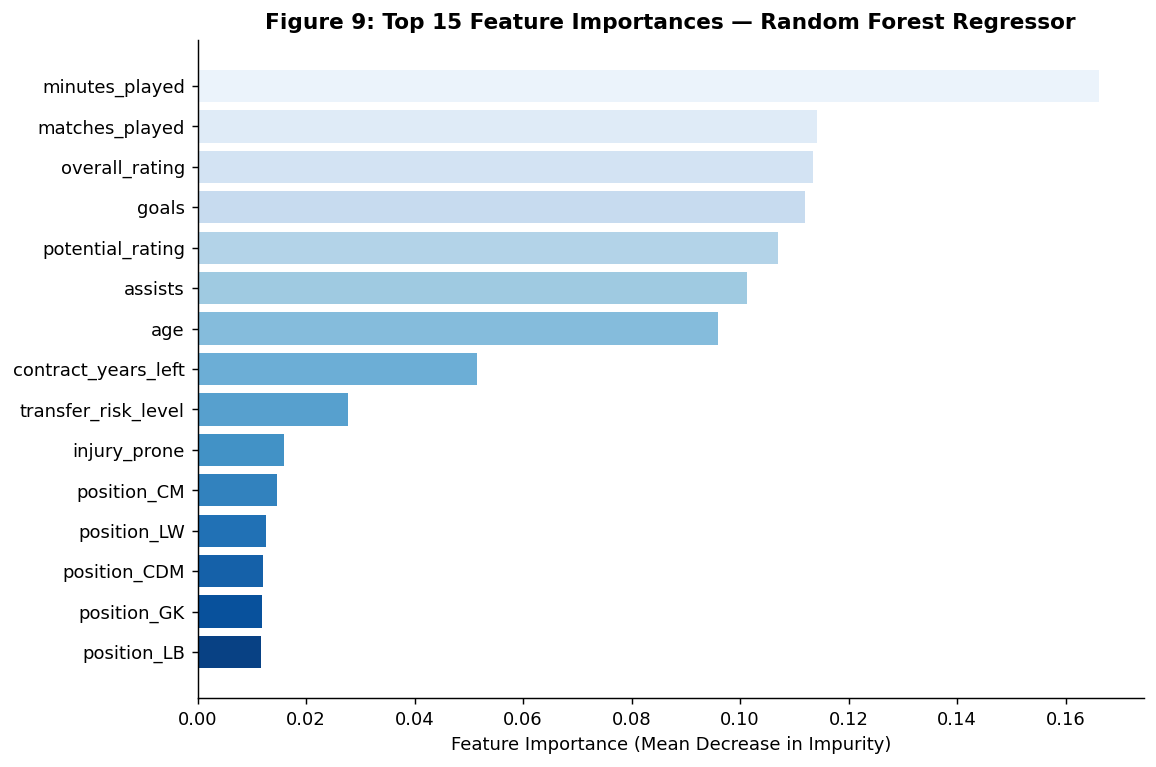

Saved: fig9_rf_feature_importance_reg.png


In [40]:
# ── Feature importance (Figure 9) ─────────────────────────────────────────
feat_imp_reg = pd.Series(
    rf_reg.feature_importances_, index=FEAT_COLS
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_reg.index, feat_imp_reg.values,
        color=sns.color_palette("Blues_r", 15))
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Figure 9: Top 15 Feature Importances — Random Forest Regressor',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_rf_feature_importance_reg.png', bbox_inches='tight')
plt.show()
print("Saved: fig9_rf_feature_importance_reg.png")

### 3.5 Model Evaluation

In [41]:
# ── Comparison table (Table 6) ─────────────────────────────────────────────
results_reg = pd.DataFrame([
    {'Model': 'Linear Regression (OLS)', 'RMSE': rmse_ols,   'MAE': mae_ols,   'R²': r2_ols},
    {'Model': 'Polynomial Regression',   'RMSE': rmse_poly,  'MAE': mae_poly,  'R²': r2_poly},
    {'Model': 'Ridge Regression',        'RMSE': rmse_ridge, 'MAE': mae_ridge, 'R²': r2_ridge},
    {'Model': 'Lasso Regression',        'RMSE': rmse_lasso, 'MAE': mae_lasso, 'R²': r2_lasso},
    {'Model': 'Random Forest',           'RMSE': rmse_rf_reg,'MAE': mae_rf_reg,'R²': r2_rf_reg},
]).round(4).sort_values('R²', ascending=False).reset_index(drop=True)

print("=== Table 6: Regression Model Performance (Test Set, log-scale target) ===")
display(results_reg)

=== Table 6: Regression Model Performance (Test Set, log-scale target) ===


,Model,RMSE,MAE,R²
0,Lasso Regression,0.8885,0.6939,-0.0020
1,Linear Regression (OLS),0.8917,0.6962,-0.0090
2,Random Forest,0.9101,0.7191,-0.0510
3,Ridge Regression,0.9125,0.7083,-0.0568
4,Polynomial Regression,0.9306,0.7231,-0.0991


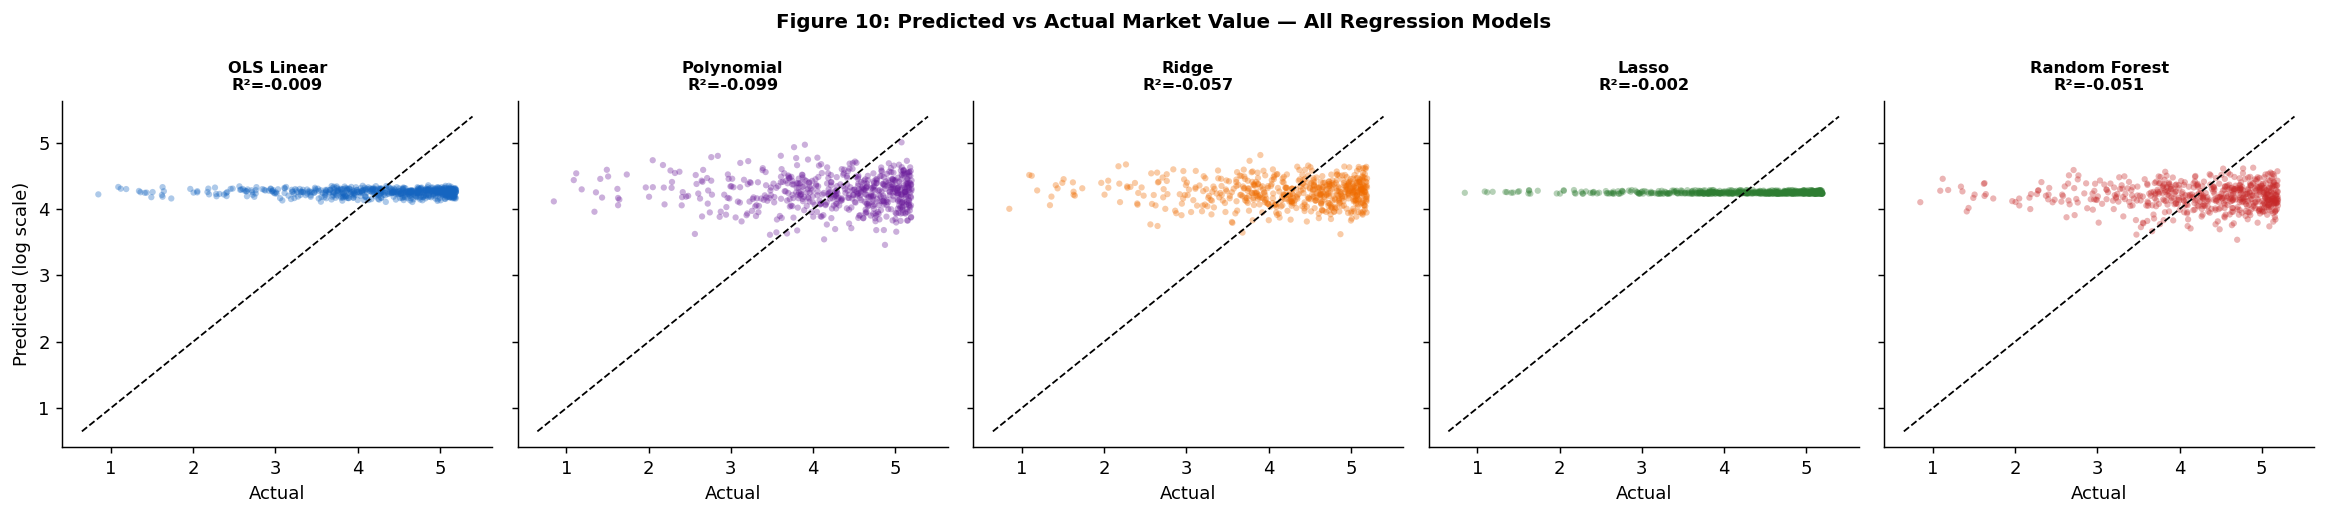

Saved: fig10_reg_predicted_vs_actual.png


In [42]:
# ── Predicted vs Actual — all 5 models (Figure 10) ────────────────────────
preds = [
    ('OLS Linear',    y_pred_ols,   '#1565C0'),
    ('Polynomial',    y_pred_poly,  '#6A1B9A'),
    ('Ridge',         y_pred_ridge, '#EF6C00'),
    ('Lasso',         y_pred_lasso, '#2E7D32'),
    ('Random Forest', y_pred_rf_reg,'#C62828')
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, (name, y_pred, color) in zip(axes, preds):
    ax.scatter(y_te_r, y_pred, alpha=0.35, s=12, c=color, edgecolors='none')
    lims = [min(y_te_r.min(), y_pred.min()) - 0.2,
            max(y_te_r.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=1)
    r2 = r2_score(y_te_r, y_pred)
    ax.set_title(f'{name}\nR²={r2:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Actual')
axes[0].set_ylabel('Predicted (log scale)')

plt.suptitle('Figure 10: Predicted vs Actual Market Value — All Regression Models',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_reg_predicted_vs_actual.png', bbox_inches='tight')
plt.show()
print("Saved: fig10_reg_predicted_vs_actual.png")

In [43]:
# ── 5-fold cross-validation on best model ─────────────────────────────────
best_model_name = results_reg.iloc[0]['Model']
print(f"Running 5-fold CV on best model: {best_model_name}")

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_reg, y_reg, cv=5, scoring='r2', n_jobs=-1
)

print(f"CV R² scores : {cv_scores.round(4)}")
print(f"Mean R²      : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")

Running 5-fold CV on best model: Lasso Regression


CV R² scores : [-0.0584 -0.0647 -0.0717 -0.033  -0.0769]
Mean R²      : -0.0610  ±  0.0153


---
## Summary of Results

Run all cells above, then fill in the tables in your Word report with the printed values.

### Figures generated
| File | Figure in Report |
|------|-----------------|
| `fig1_pca_scree.png` | Figure 1: PCA Scree Plot |
| `fig2_elbow_silhouette.png` | Figure 2: Elbow & Silhouette |
| `fig3_kmeans_pca.png` | Figure 3: K-Means PCA Projection |
| `fig4_dendrogram.png` | Figure 4: HAC Dendrogram |
| `fig5_rf_feature_importance_clf.png` | Figure 5: RF Feature Importance (Classification) |
| `fig6_confusion_matrices.png` | Figure 6: Confusion Matrices |
| `fig7_roc_curves_clf.png` | Figure 7: ROC Curves |
| `fig8_target_distribution.png` | Figure 8: Target Distribution |
| `fig9_rf_feature_importance_reg.png` | Figure 9: RF Feature Importance (Regression) |
| `fig10_reg_predicted_vs_actual.png` | Figure 10: Predicted vs Actual |

> **Remember:** Replace `[YOUR CANDIDATE NUMBER]` on the title page before submission.
